![image info](https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/images/banner_1.png)

# Proyecto 1 - Predicción de popularidad en canción

En este proyecto podrán poner en práctica sus conocimientos sobre modelos predictivos basados en árboles y ensambles, y sobre la disponibilización de modelos. Para su desarrollo tengan en cuenta las instrucciones dadas en la "Guía del proyecto 1: Predicción de popularidad en canción".

**Entrega**: La entrega del proyecto deberán realizarla durante la semana 4. Sin embargo, es importante que avancen en la semana 3 en el modelado del problema y en parte del informe, tal y como se les indicó en la guía.

Para hacer la entrega, deberán adjuntar el informe autocontenido en PDF a la actividad de entrega del proyecto que encontrarán en la semana 4, y subir el archivo de predicciones a la [competencia de Kaggle](https://www.kaggle.com/competitions/miad-2025-12-prediccion-popularidad-en-cancion).

## Datos para la predicción de popularidad en cancion

En este proyecto se usará el conjunto de datos de datos de popularidad en canciones, donde cada observación representa una canción y se tienen variables como: duración de la canción, acusticidad y tempo, entre otras. El objetivo es predecir qué tan popular es la canción. Para más detalles puede visitar el siguiente enlace: [datos](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset).

## Ejemplo predicción conjunto de test para envío a Kaggle

En esta sección encontrarán el formato en el que deben guardar los resultados de la predicción para que puedan subirlos a la competencia en Kaggle.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación librerías
import pandas as pd
import numpy as np

In [4]:
# Carga de datos de archivo .csv
dataTraining = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2025/main/datasets/dataTrain_Spotify.csv')
dataTesting = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2025/main/datasets/dataTest_Spotify.csv', index_col=0)

In [5]:
# Visualización datos de entrenamiento
dataTraining.head()

,Unnamed: 0,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity
0,0,7hUhmkALyQ8SX9mJs5XI3D,Love and Rockets,Love and Rockets,Motorcycle,211533,False,0.305,0.8490,9,...,1,0.0549,0.000058,0.056700,0.4640,0.3200,141.793,4,goth,22
1,1,5x59U89ZnjZXuNAAlc8X1u,Filippa Giordano,Filippa Giordano,"Addio del passato - From ""La traviata""",196000,False,0.287,0.1900,7,...,0,0.0370,0.930000,0.000356,0.0834,0.1330,83.685,4,opera,22
2,2,70Vng5jLzoJLmeLu3ayBQq,Susumu Yokota,Symbol,Purple Rose Minuet,216506,False,0.583,0.5090,1,...,1,0.0362,0.777000,0.202000,0.1150,0.5440,90.459,3,idm,37
3,3,1cRfzLJapgtwJ61xszs37b,Franz Liszt;YUNDI,Relajación y siestas,"Liebeslied (Widmung), S. 566",218346,False,0.163,0.0368,8,...,1,0.0472,0.991000,0.899000,0.1070,0.0387,69.442,3,classical,0
4,4,47d5lYjbiMy0EdMRV8lRou,Scooter,Scooter Forever,The Darkside,173160,False,0.647,0.9210,2,...,1,0.1850,0.000939,0.371000,0.1310,0.1710,137.981,4,techno,27


In [6]:
# Visualización datos de test
dataTesting.head()

,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,6KwkVtXm8OUp2XffN5k7lY,Hillsong Worship,No Other Name,No Other Name,440247,False,0.369,0.598,7,-6.984,1,0.0304,0.00511,0.000000,0.176,0.0466,148.014,4,world-music
1,2dp5I5MJ8bQQHDoFaNRFtX,Internal Rot,Grieving Birth,Failed Organum,93933,False,0.171,0.997,7,-3.586,1,0.1180,0.00521,0.801000,0.420,0.0294,122.223,4,grindcore
2,5avw06usmFkFrPjX8NxC40,Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,"Save the Trees, Pt. 1",213578,False,0.173,0.803,9,-10.071,0,0.1440,0.61300,0.001910,0.195,0.0887,75.564,3,iranian
3,75hT0hvlESnDJstem0JgyR,Bryan Adams,All I Want For Christmas Is You,Merry Christmas,151387,False,0.683,0.511,6,-5.598,1,0.0279,0.40600,0.000197,0.111,0.5980,109.991,3,rock
4,4bY2oZGA5Br3pTE1Jd1IfY,Nogizaka46,バレッタ TypeD,月の大きさ,236293,False,0.555,0.941,9,-3.294,0,0.0481,0.48400,0.000000,0.266,0.8130,92.487,4,j-idol


In [ ]:
# Predicción del conjunto de test - acá se genera un número aleatorio como ejemplo
np.random.seed(42)
y_pred = pd.DataFrame(np.random.rand(dataTesting.shape[0]) * 100, index=dataTesting.index, columns=['Popularity'])

In [ ]:
# Guardar predicciones en formato exigido en la competencia de kaggle
y_pred.to_csv('test_submission_file.csv', index_label='ID')
y_pred.head()

# Desarrollo LO

In [7]:
dataTraining.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79800 entries, 0 to 79799
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        79800 non-null  int64  
 1   track_id          79800 non-null  object 
 2   artists           79800 non-null  object 
 3   album_name        79800 non-null  object 
 4   track_name        79800 non-null  object 
 5   duration_ms       79800 non-null  int64  
 6   explicit          79800 non-null  bool   
 7   danceability      79800 non-null  float64
 8   energy            79800 non-null  float64
 9   key               79800 non-null  int64  
 10  loudness          79800 non-null  float64
 11  mode              79800 non-null  int64  
 12  speechiness       79800 non-null  float64
 13  acousticness      79800 non-null  float64
 14  instrumentalness  79800 non-null  float64
 15  liveness          79800 non-null  float64
 16  valence           79800 non-null  float6

In [85]:
# Se cambian tipos de datos para variables que deben ser categoricas
dataTraining['key'] = dataTraining['key'].astype('category')
dataTraining['mode'] = dataTraining['mode'].astype('category')
dataTraining['time_signature'] = dataTraining['time_signature'].astype('category')
dataTraining['artists'] = dataTraining['artists'].astype('category')
dataTraining['track_name'] = dataTraining['track_name'].astype('category')
dataTraining['album_name'] = dataTraining['album_name'].astype('category')
dataTraining['track_genre'] = dataTraining['track_genre'].astype('category')
dataTraining['explicit'] = dataTraining['explicit'].astype('category')

# Se elimina la columna 'track_id' ya que no es necesaria para el modelo
Training = dataTraining.drop(columns=['track_id'])
Training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79800 entries, 0 to 79799
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Unnamed: 0        79800 non-null  int64   
 1   artists           79800 non-null  category
 2   album_name        79800 non-null  category
 3   track_name        79800 non-null  category
 4   duration_ms       79800 non-null  int64   
 5   explicit          79800 non-null  category
 6   danceability      79800 non-null  float64 
 7   energy            79800 non-null  float64 
 8   key               79800 non-null  category
 9   loudness          79800 non-null  float64 
 10  mode              79800 non-null  category
 11  speechiness       79800 non-null  float64 
 12  acousticness      79800 non-null  float64 
 13  instrumentalness  79800 non-null  float64 
 14  liveness          79800 non-null  float64 
 15  valence           79800 non-null  float64 
 16  tempo             7980

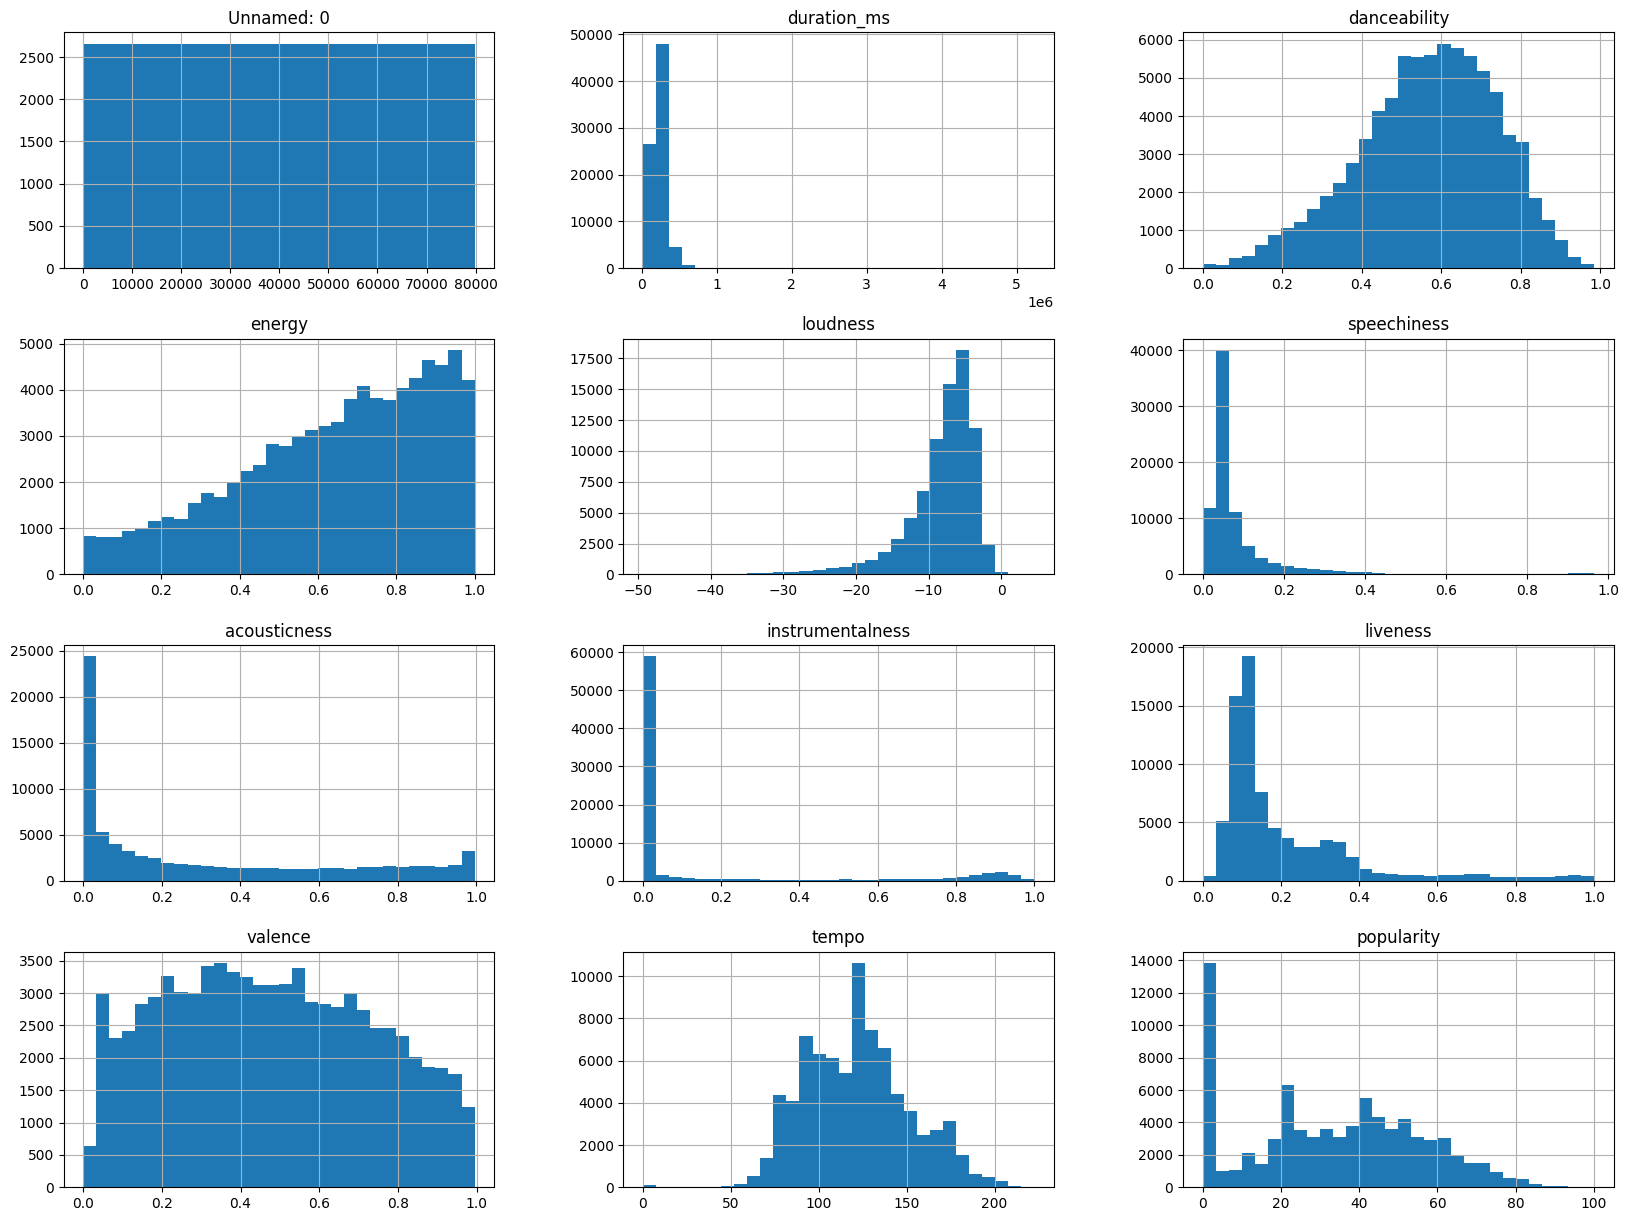

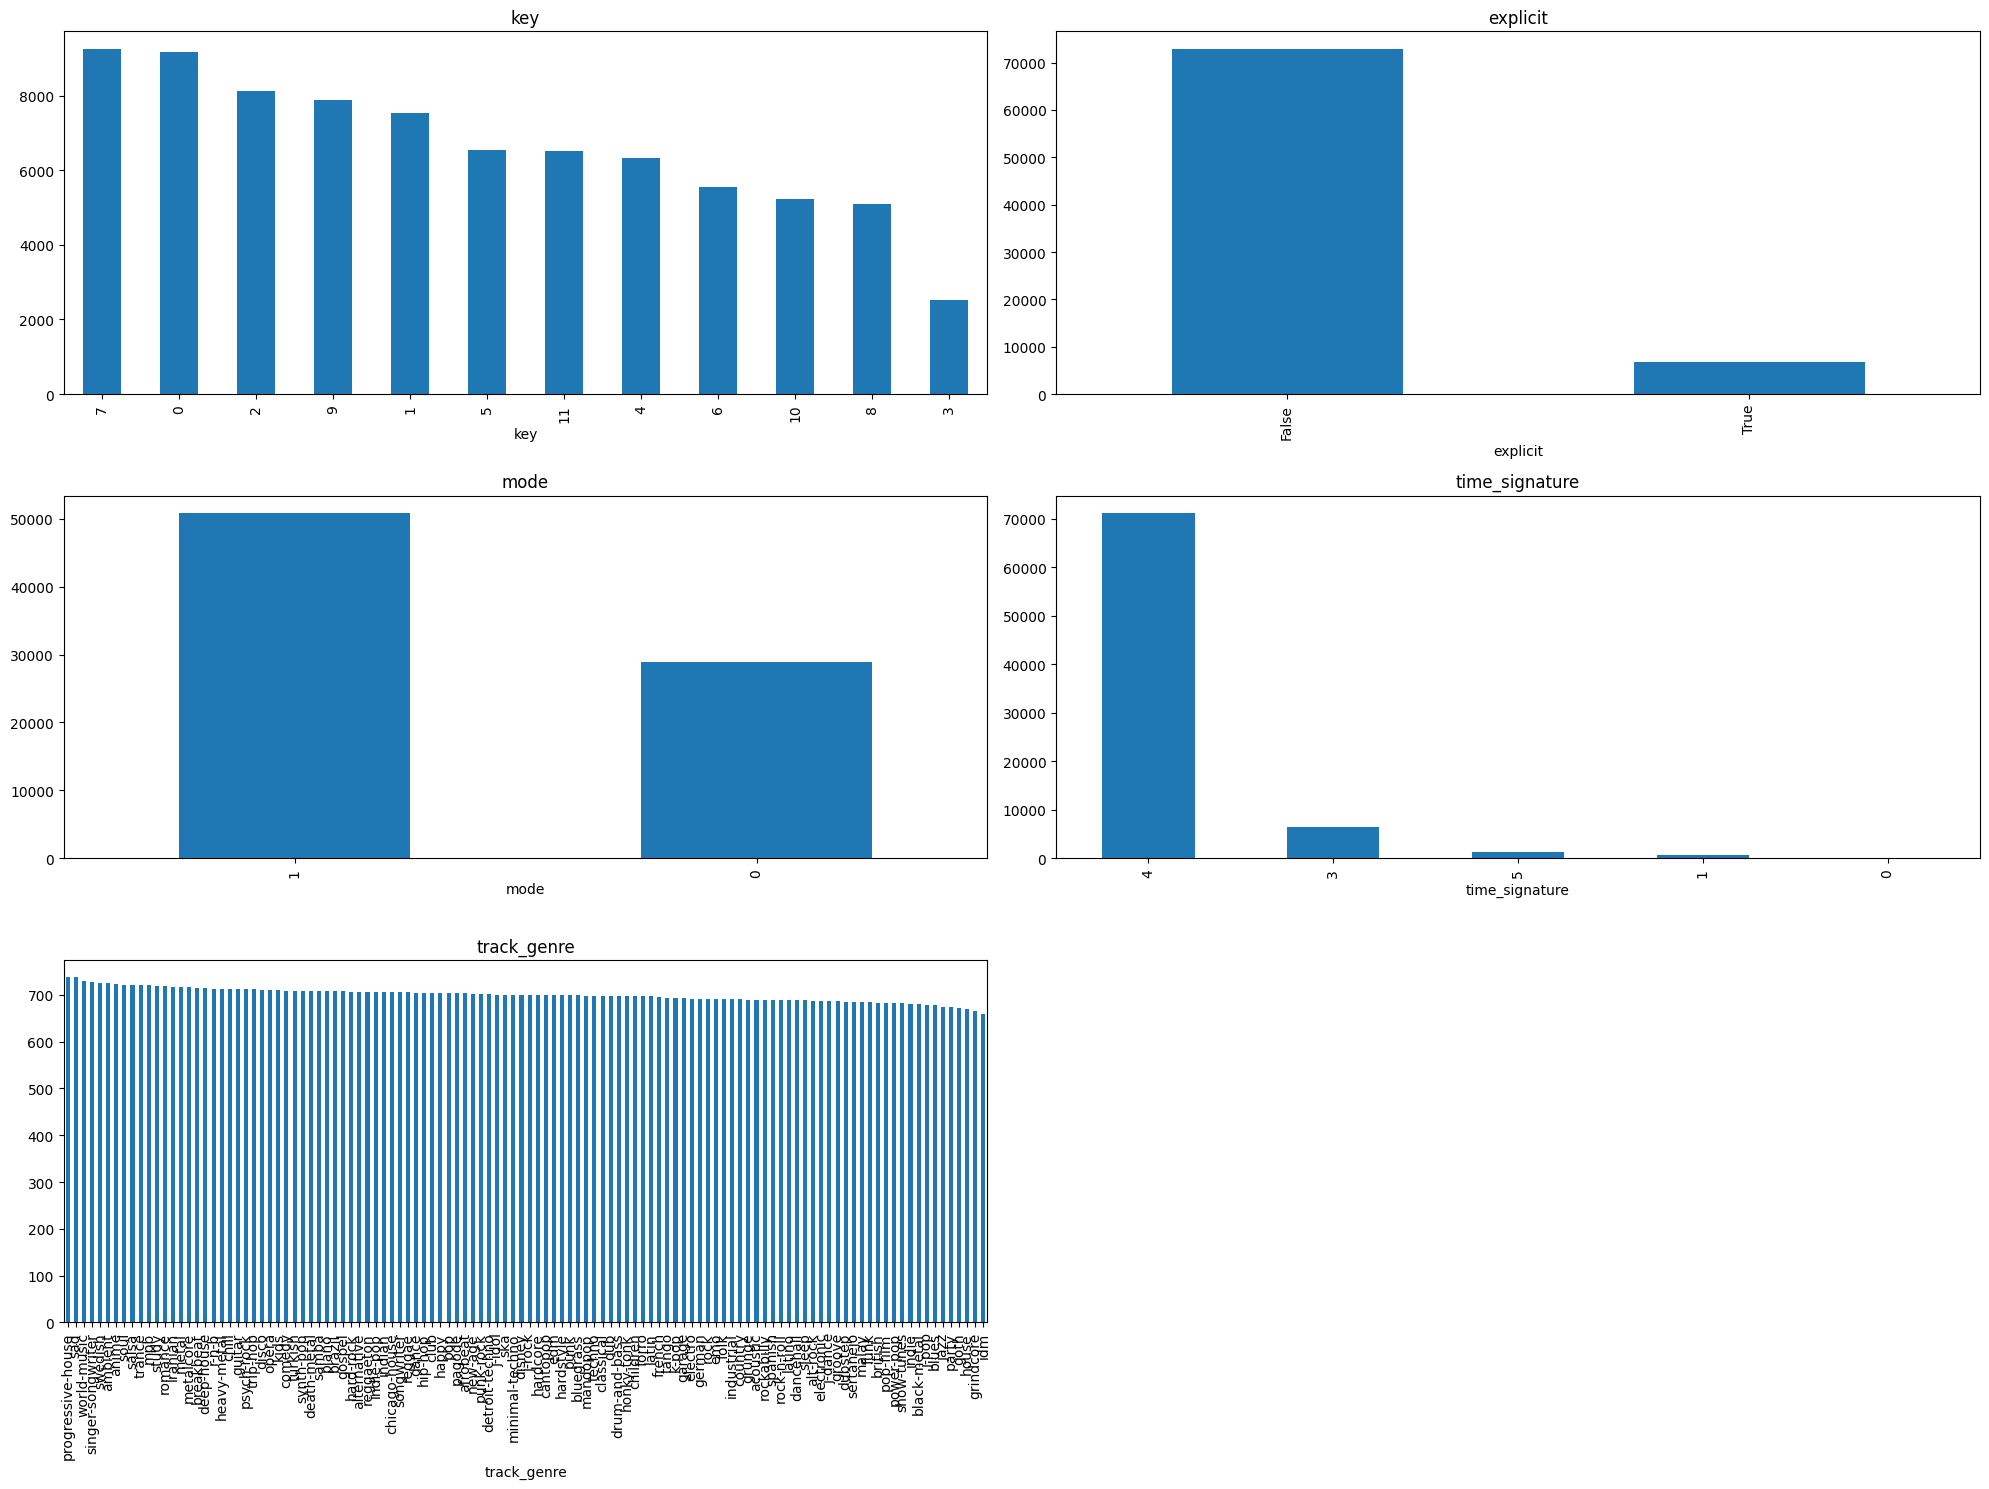

In [86]:
# Se generan histogramas para las variables numéricas
Training.hist(figsize=(20, 15), bins=30)
import matplotlib.pyplot as plt
plt.show()

# Se generan histogramas para las variables categóricas
fig, axes = plt.subplots(3, 2, figsize=(20, 15))
axes = axes.flatten()

Training['key'].value_counts().plot(kind='bar', ax=axes[0], title='key')
Training['explicit'].value_counts().plot(kind='bar', ax=axes[1], title='explicit')
Training['mode'].value_counts().plot(kind='bar', ax=axes[2], title='mode')
Training['time_signature'].value_counts().plot(kind='bar', ax=axes[3], title='time_signature')
Training['track_genre'].value_counts().plot(kind='bar', ax=axes[4], title='track_genre')

# Ocultar el último subplot vacío si hay menos gráficos que subplots
if len(axes) > 5:
    axes[5].axis('off')

plt.tight_layout()
plt.show()

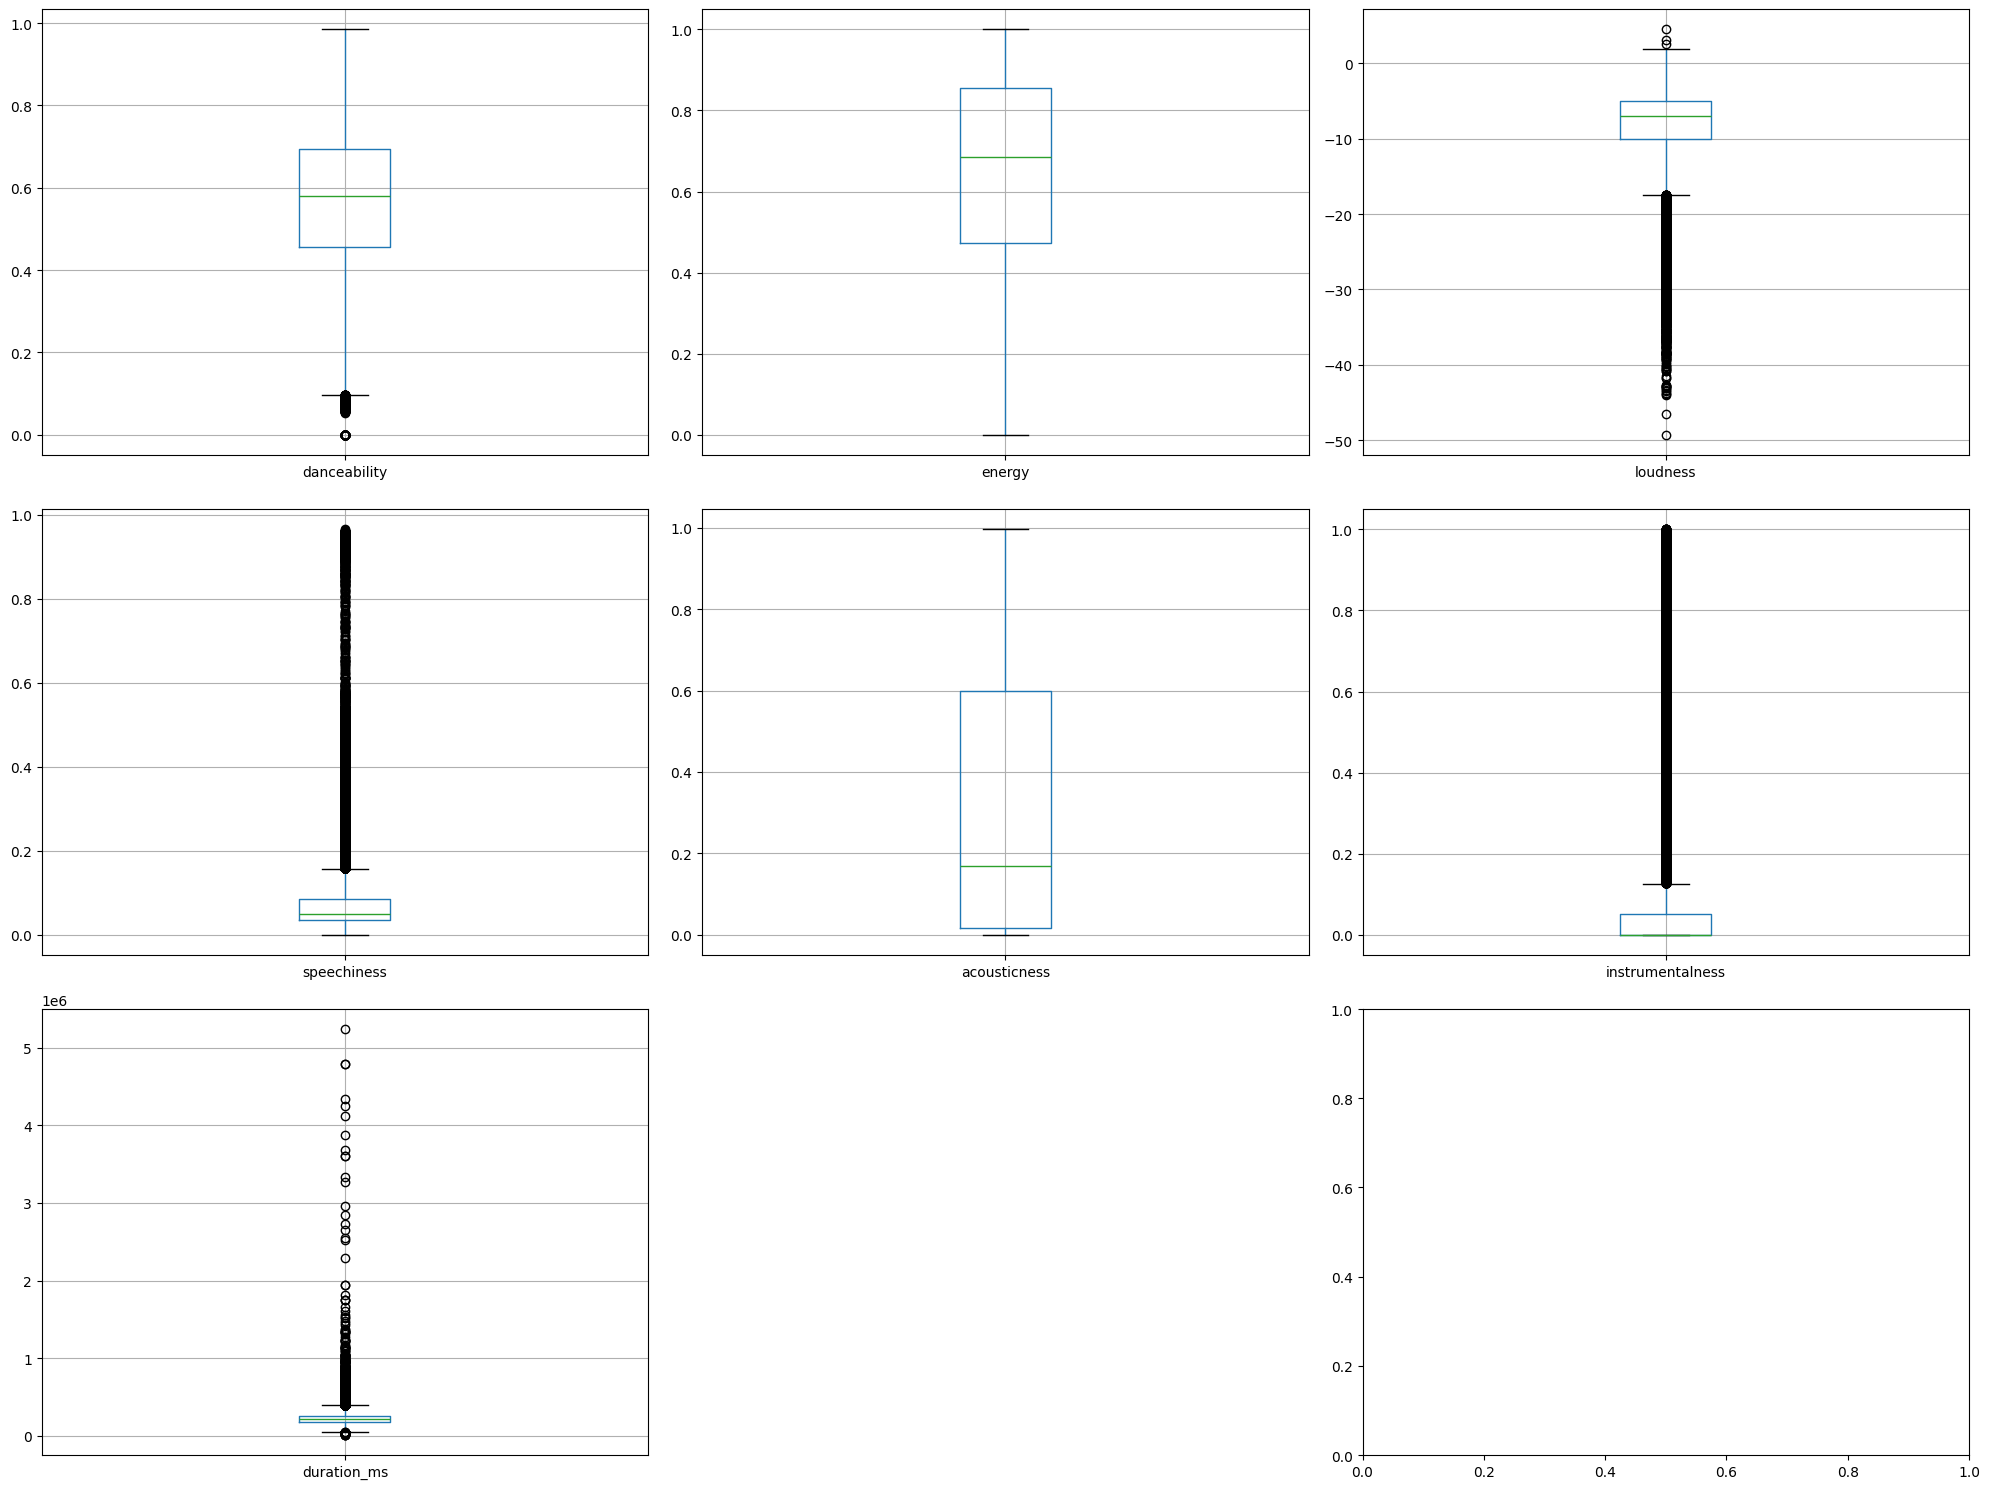

In [46]:
# Visualizar bloxplot de variables numericas para ver outliers
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()

Training.boxplot(column='danceability', ax=axes[0])
Training.boxplot(column='energy', ax=axes[1])
Training.boxplot(column='loudness', ax=axes[2])
Training.boxplot(column='speechiness', ax=axes[3])
Training.boxplot(column='acousticness', ax=axes[4])
Training.boxplot(column='instrumentalness', ax=axes[5])
Training.boxplot(column='duration_ms', ax=axes[6])
# Ocultar el último subplot vacío si hay menos gráficos que subplots
if len(axes) > 7:
    axes[7].axis('off')
plt.tight_layout()
plt.show()

In [87]:
categorical_cols = Training.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    print(col, Training[col].nunique())

artists 25775
album_name 37315
track_name 55767
explicit 2
key 12
mode 2
time_signature 5
track_genre 114


In [ ]:
Training['n_artists'] = Training['artists'].apply(lambda x: len(str(x).split(';')))
Training['album_name_len'] = Training['album_name'].str.len()
Training['album_name_words'] = Training['album_name'].str.split().str.len()
Training['track_name_len'] = Training['track_name'].str.len()
Training['track_name_words'] = Training['track_name'].str.split().str.len()
Training['first_artist'] = Training['artists'].str.split(';').str[0]

def clasificar(n):
    if n <= 3:
        return '0-3'
    elif n <= 7:
        return '4-7'
    elif n <= 10:
        return '8-10'
    else:
        return '>10'

Training['clasificacion_artistas'] = Training['n_artists'].apply(clasificar)

In [91]:
# Generar las columnas dummies
dummies = pd.get_dummies(Training[['explicit', 'key', 'mode', 'time_signature', 'clasificacion_artistas', 'track_genre']], drop_first=True).astype(int)

# Eliminar las columnas originales
Training.drop(['explicit', 'key', 'mode', 'time_signature', 'clasificacion_artistas'], axis=1, inplace=True)

# Concatenar las columnas dummies con el resto del DataFrame
Training = pd.concat([Training, dummies], axis=1)
Training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79800 entries, 0 to 79799
Columns: 155 entries, Unnamed: 0 to track_genre_world-music
dtypes: category(4), float64(9), int64(141), object(1)
memory usage: 97.7+ MB


In [92]:
print(Training.columns)

Index(['Unnamed: 0', 'artists', 'album_name', 'track_name', 'duration_ms',
       'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
       ...
       'track_genre_spanish', 'track_genre_study', 'track_genre_swedish',
       'track_genre_synth-pop', 'track_genre_tango', 'track_genre_techno',
       'track_genre_trance', 'track_genre_trip-hop', 'track_genre_turkish',
       'track_genre_world-music'],
      dtype='object', length=155)


In [93]:
# Se aplica una transformacion logaritmica a la columna duration_ms tanto en train como en test
Training['duration_ms'] = np.log1p(Training['duration_ms'])

In [94]:
# Se eliminan columnas innecesarias
Training.drop(columns=['Unnamed: 0', 'first_artist'], inplace=True)

In [95]:
# Generar la pratición de los datos en train y test
from sklearn.model_selection import train_test_split
X = Training.drop(columns=['popularity', 'track_name'])
y = Training['popularity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [96]:
# Calcular la popularidad promedio por artista usando SOLO el conjunto de entrenamiento
artist_popularity = (
    X_train.assign(artist=X_train['artists'].str.split(';'))
    .explode('artist')
    .join(y_train, how='left')                        # unir la popularidad objetivo
    .groupby('artist')['popularity']
    .mean()
)

# Función para codificar
def compute_artists_mean_popularity(artists_string):
    artists = artists_string.split(';')
    popularities = [artist_popularity.get(artist, artist_popularity.mean()) for artist in artists]
    return sum(popularities) / len(popularities)

# Aplicar la función a ambas particiones
X_train = X_train.copy()
X_test = X_test.copy()

X_train['artists_encoded'] = X_train['artists'].apply(compute_artists_mean_popularity)
X_test['artists_encoded'] = X_test['artists'].apply(compute_artists_mean_popularity)

# Eliminar columnas innecesarias
X_train.drop(columns=['artists'], inplace=True)
X_test.drop(columns=['artists'], inplace=True)

In [97]:
from category_encoders import TargetEncoder

# Se usa TargetEncoder para las dos columnas categóricas track_genre y first_artist
encoder = TargetEncoder(cols=['track_genre', 'album_name'])

# Se ajusta usando solo el conjunto de entrenamiento
X_train_encoded = X_train.copy()
X_train_encoded[['track_genre', 'album_name']] = encoder.fit_transform(X_train[['track_genre', 'album_name']], y_train)

# Transformar el conjunto de prueba (sin ajustar de nuevo para evitar el leakage)
X_test_encoded = X_test.copy()
X_test_encoded[['track_genre', 'album_name']] = encoder.transform(X_test[['track_genre', 'album_name']])

In [99]:
X_train_encoded.head()

,album_name,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,...,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music,artists_encoded
23491,37.109727,12.601491,0.383,0.836,-4.788,0.0468,0.1010,0.00000,0.2290,0.260,...,0,0,0,0,0,0,0,0,1,51.847826
72887,35.103525,12.569420,0.608,0.592,-9.642,0.0409,0.4690,0.90900,0.0651,0.365,...,0,0,0,0,0,0,0,0,0,47.000000
54394,6.900824,11.298494,0.537,0.110,-25.941,0.0605,0.9910,0.84800,0.1190,0.890,...,0,0,0,0,0,0,0,0,0,10.263981
43696,35.621471,12.495457,0.582,0.813,-4.558,0.0295,0.0819,0.00119,0.9020,0.345,...,0,0,0,0,0,0,0,0,0,42.803030
45363,37.847227,11.963899,0.677,0.256,-16.915,0.0448,0.9480,0.00001,0.0926,0.318,...,0,0,0,0,0,0,0,0,0,51.057143


In [100]:
X_train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63840 entries, 23491 to 15795
Columns: 151 entries, album_name to artists_encoded
dtypes: float64(13), int64(138)
memory usage: 74.0 MB


In [102]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from scipy.stats import randint, uniform
import numpy as np

# Definir el modelo base
rf = RandomForestRegressor(random_state=42)

# Definir espacio de búsqueda de hiperparámetros
param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': [None, 10, 20, 30],
    'max_features': ['sqrt', 'log2', uniform(0.5, 0.4)],  # 0.5 a 0.9
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

# Configurar búsqueda aleatoria
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_root_mean_squared_error',  # más directa para RMSE
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Entrenar el modelo con validación cruzada
random_search.fit(X_train_encoded, y_train)

# Obtener los mejores hiperparámetros
best_rf = random_search.best_estimator_
print("Mejores hiperparámetros:", random_search.best_params_)

# Predicciones y métricas
y_pred = best_rf.predict(X_test_encoded)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f" RMSE del mejor modelo Random Forest: {rmse:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Mejores hiperparámetros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 289}
 RMSE del mejor modelo Random Forest: 9.8866


In [101]:
rf = RandomForestRegressor(max_features='sqrt', n_estimators=241, random_state=42)
rf.fit(X_train_encoded, y_train)
y_pred = rf.predict(X_test_encoded)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f" RMSE del modelo Random Forest: {rmse:.4f}")

 RMSE del modelo Random Forest: 9.9093


In [ ]:
# Generar un modelo de XGBoost
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

XGB_modelo = xgb.XGBRegressor(objective='reg:squarederror')

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=XGB_modelo,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_encoded, y_train)

best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test_encoded)

print("Mejores hiperparámetros:", grid_search.best_params_)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

In [ ]:
from sklearn.metrics import root_mean_squared_error
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Configurar el modelo base
rf = RandomForestRegressor(
    oob_score=True,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# Definir grilla de hiperparámetros
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

# Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",  # para RMSE negativo (se convierte en positivo después)
    cv=5,
    verbose=2,
    n_jobs=-1
)

# Entrenar la búsqueda
grid_search.fit(X_train_encoded, y_train)

# Mejor modelo
best_rf = grid_search.best_estimator_

# Mostrar resultados
print("Mejores hiperparámetros:", grid_search.best_params_)
print(f"OOB R² del mejor modelo: {best_rf.oob_score_:.4f}")

# Evaluación en test
y_pred = best_rf.predict(X_test_encoded)
# rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

# print(f"Test RMSE: {rmse:.2f}")
print(f"Test R²: {r2:.4f}")

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import numpy as np

def calibrar_modelo(modelo_nombre, X_train, y_train, X_test, y_test, n_iter=20, cv=5, verbose=3):
    if modelo_nombre == 'random_forest':
        modelo = RandomForestRegressor(oob_score=True, bootstrap=True, random_state=42)
        param_dist = {
            'n_estimators': randint(100, 300),
            'max_depth': [None, 10, 20, 30],
            'max_features': ['sqrt', 'log2', uniform(0.5, 0.4)],
            'min_samples_split': randint(2, 10),
            'min_samples_leaf': randint(1, 5)
        }
    elif modelo_nombre == 'xgboost':
        modelo = XGBRegressor(random_state=42, verbosity=0, n_jobs=-1)
        param_dist = {
            'n_estimators': randint(0, 300),
            'max_depth': randint(1, 12),
            'learning_rate': uniform(0.005, 0.3),
            'gamma': uniform(0, 0.5),
            'colsample_bytree': uniform(0.3, 0.8)
        }
    else:
        raise ValueError("Modelo no soportado. Usa 'random_forest' o 'xgboost'.")

    # Configurar búsqueda aleatoria
    random_search = RandomizedSearchCV(
        estimator=modelo,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=cv,
        verbose=verbose,
        random_state=42,
        n_jobs=-1,
        scoring='neg_root_mean_squared_error'
    )

    # Entrenar modelo
    random_search.fit(X_train, y_train)
    best_model = random_search.best_estimator_

    print("\n Mejores hiperparámetros:", random_search.best_params_)
    print(" Mejor RMSE (negativo CV):", random_search.best_score_)

    # OOB score si aplica
    if modelo_nombre == 'random_forest':
        print(" OOB Score:", best_model.oob_score_)

    # Evaluación final
    y_pred = best_model.predict(X_test)
    print("\n Evaluación en test:")
    print("RMSE:", root_mean_squared_error(y_test, y_pred))
    print("R²:", r2_score(y_test, y_pred))

    return best_model

In [ ]:
modelo_rf = calibrar_modelo('random_forest', X_train_encoded, y_train, X_test_encoded, y_test, n_iter=20, cv=5, verbose=3)

In [ ]:
modelo_xgb = calibrar_modelo('xgboost', X_train_encoded, y_train, X_test_encoded, y_test, n_iter=10, cv=3, verbose=3)